# Used Car Performance and Efficiency Analysis

## Introduction

This project explores a dataset of used cars to understand their performance,
fuel efficiency, engine characteristics, and usage patterns.

The analysis focuses on identifying relationships between variables such as
manufacturing year, mileage, horsepower, torque, engine capacity, and fuel
efficiency.

The main objectives of this project are:

- Understand and clean the dataset.
- Explore the distribution of cars across different brands and models.
- Analyze manufacturing year and mileage patterns.
- Compare city and highway fuel efficiency.
- Study the relationship between engine capacity, horsepower, and torque.
- Identify correlations between important numerical variables.
- Draw meaningful insights from the data using visualizations.

### Tools and Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 1. Importing Required Libraries

The following Python libraries are used for data manipulation, numerical
analysis, and visualization.

- **Pandas** is used for loading and manipulating the dataset.
- **NumPy** is used for numerical operations.
- **Matplotlib** is used to create visualizations.
- **Seaborn** is used to create statistical visualizations.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Display floating-point values neatly
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Loading the Dataset

The dataset is stored in CSV format. It contains information about used cars, including their brand, model, manufacturing year, mileage, fuel efficiency,horsepower, torque, and engine capacity.

In [13]:
df = pd.read_csv("used_cars-selected-columns.csv")

df.head()

,id,brand,model,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre
0,3,Chevrolet,Volt LT,2019,27173,43,42,149,294,1.50
1,6,Hyundai,Elantra SE,2017,76941,29,38,146,132,2.00
2,7,Ford,Focus,2014,97027,27,37,159,146,2.00
3,8,Honda,Civic,2016,95396,31,42,158,138,1.50
4,9,Hyundai,Elantra SE,2019,28405,29,38,147,132,2.00


## 3. Understanding the Dataset

Before performing any analysis, it is important to understand the structure
of the dataset.

We will examine:

- Number of rows and columns
- Column names
- Data types
- Basic statistical information
- Missing values
- Duplicate records

In [14]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 52
Number of columns: 10


In [15]:
df.columns

Index(['id', 'brand', 'model', 'year', 'miles', 'city_mileage',
       'highway_mileage', 'horsepower', 'torque', 'engine_capacity_litre'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     52 non-null     int64  
 1   brand                  52 non-null     object 
 2   model                  52 non-null     object 
 3   year                   52 non-null     int64  
 4   miles                  52 non-null     int64  
 5   city_mileage           52 non-null     int64  
 6   highway_mileage        52 non-null     int64  
 7   horsepower             52 non-null     int64  
 8   torque                 52 non-null     int64  
 9   engine_capacity_litre  52 non-null     float64
dtypes: float64(1), int64(7), object(2)
memory usage: 4.2+ KB


In [5]:
df.describe()

,id,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre
count,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00
mean,31.37,2018.67,33901.25,29.04,37.42,176.87,177.92,1.83
std,15.38,1.40,22700.65,5.95,4.14,33.79,47.26,0.38
min,3.00,2014.00,5000.00,17.00,24.00,143.00,99.00,1.40
25%,18.75,2018.00,16454.75,26.50,35.75,152.00,138.00,1.50
50%,31.50,2019.00,27448.50,30.00,38.00,159.50,181.00,2.00
75%,44.25,2019.25,42442.00,30.00,40.00,192.00,192.00,2.00
max,57.00,2022.00,97027.00,55.00,49.00,288.00,294.00,3.50


## 4. Checking for Missing Values

Missing values can affect the accuracy of data analysis. Therefore, we check
each column to determine whether any values are missing.

In [17]:
missing_values = df.isnull().sum()

missing_values

id                       0
brand                    0
model                    0
year                     0
miles                    0
city_mileage             0
highway_mileage          0
horsepower               0
torque                   0
engine_capacity_litre    0
dtype: int64

### Observation

The dataset does not contain missing values. Therefore, no missing-value
imputation or removal is required.

## 5. Checking for Duplicate Records

Duplicate records can lead to incorrect conclusions because the same car may
be counted more than once. Therefore, duplicate rows are checked before
continuing with the analysis.

In [18]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Observation

The dataset does not contain duplicate rows, so no duplicate records need to
be removed.

## 6. Data Cleaning

The dataset was inspected for missing values, duplicate records, and
inappropriate data types.

Since the dataset contains no missing values or duplicate rows and the
numerical and categorical columns have appropriate data types, no major
cleaning operation is required.

The `id` column identifies each car and is not required for statistical
relationships between the other variables.

In [19]:
# Create a copy for analysis
cars = df.copy()

# Remove ID because it is only an identifier and does not represent
# a meaningful characteristic of the car
cars = cars.drop(columns=["id"])

cars.head()

,brand,model,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre
0,Chevrolet,Volt LT,2019,27173,43,42,149,294,1.50
1,Hyundai,Elantra SE,2017,76941,29,38,146,132,2.00
2,Ford,Focus,2014,97027,27,37,159,146,2.00
3,Honda,Civic,2016,95396,31,42,158,138,1.50
4,Hyundai,Elantra SE,2019,28405,29,38,147,132,2.00


## 7. Brand Distribution

First, we examine how many cars from each brand are present in the dataset.

This helps us understand whether the dataset is evenly distributed across
brands or whether some brands are represented more frequently.

In [20]:
brand_counts = cars["brand"].value_counts()

brand_counts

brand
Honda         23
Volkswagen    11
Hyundai        7
Ford           5
Chevrolet      3
Subaru         3
Name: count, dtype: int64

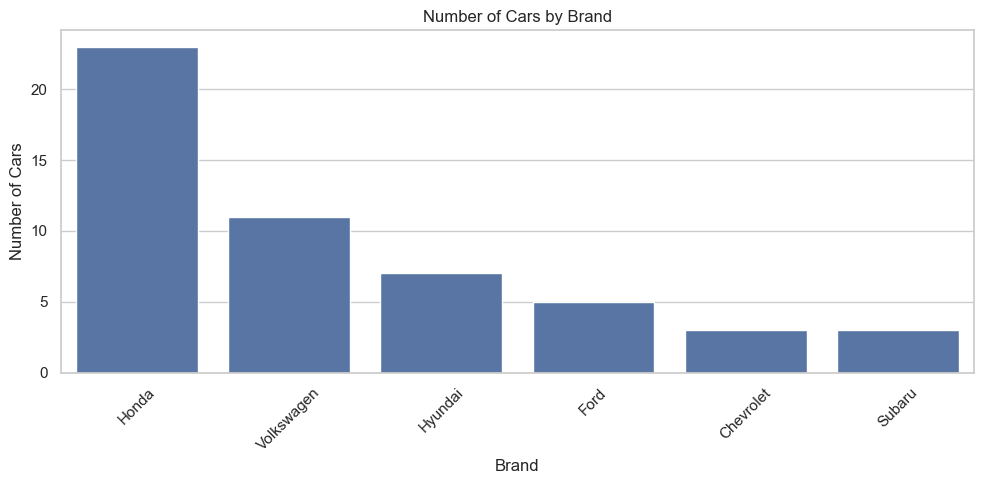

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=cars,
    x="brand",
    order=brand_counts.index
)

plt.title("Number of Cars by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis

The bar chart shows the number of cars available from each brand in the
dataset. The distribution is not necessarily equal across all brands, so
comparisons between brands should take the number of observations into
account.

## 8. Model Distribution

The dataset contains multiple car models. Examining model frequency helps us
understand which models occur most frequently in the dataset.

In [22]:
model_counts = cars["model"].value_counts()

model_counts

model
Civic         14
Jetta          7
Accord         7
Passat         4
Elantra SE     4
Sonata         3
Fusion         3
Impreza        2
Malibu         2
Volt LT        1
Focus          1
Clarity        1
Legacy         1
Taurus         1
Insight        1
Name: count, dtype: int64

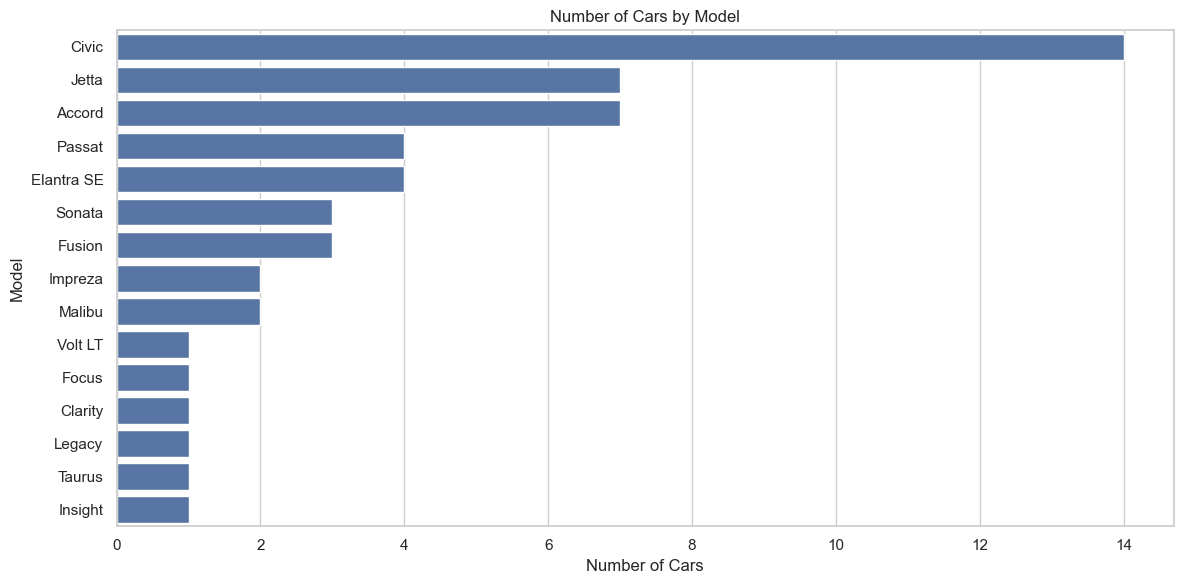

In [23]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=cars,
    y="model",
    order=model_counts.index
)

plt.title("Number of Cars by Model")
plt.xlabel("Number of Cars")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 9. Manufacturing Year Analysis

The manufacturing year provides information about the age of the cars in the
dataset.

We analyze the distribution of manufacturing years to understand whether the
dataset mainly contains older or newer vehicles.

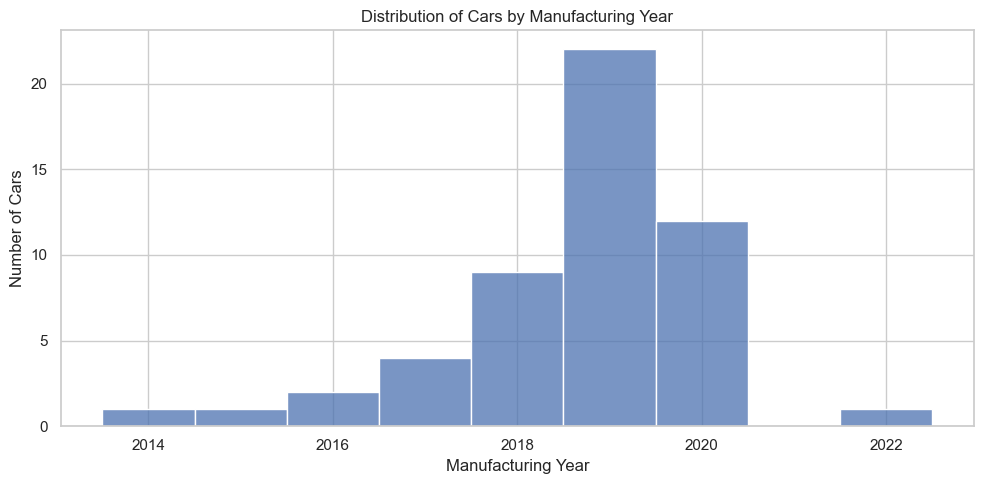

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=cars,
    x="year",
    bins=10,
    discrete=True
)

plt.title("Distribution of Cars by Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

In [25]:
cars["year"].value_counts().sort_index()

year
2014     1
2015     1
2016     2
2017     4
2018     9
2019    22
2020    12
2022     1
Name: count, dtype: int64

### Analysis

The distribution shows the manufacturing years represented in the dataset. This helps us understand the age range of the vehicles included in the
analysis.

## 10. Mileage Analysis

The `miles` column represents the distance travelled by each vehicle.

We analyze its distribution to understand how mileage varies among the cars.

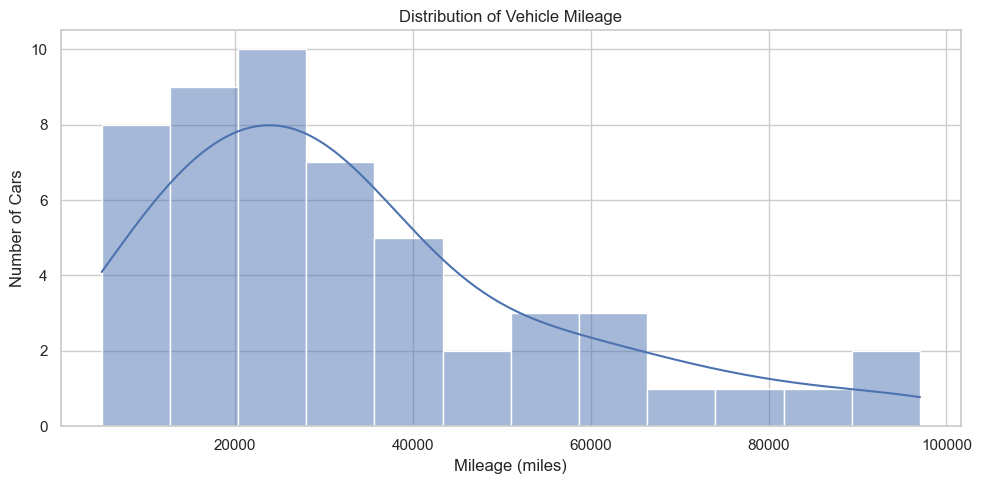

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=cars,
    x="miles",
    bins=12,
    kde=True
)

plt.title("Distribution of Vehicle Mileage")
plt.xlabel("Mileage (miles)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

In [27]:
cars["miles"].describe()

count      52.00
mean    33901.25
std     22700.65
min      5000.00
25%     16454.75
50%     27448.50
75%     42442.00
max     97027.00
Name: miles, dtype: float64

## 11. Manufacturing Year vs Mileage

A useful question is whether newer cars in the dataset tend to have lower
mileage.

A scatter plot is appropriate because both manufacturing year and mileage are
numerical variables.

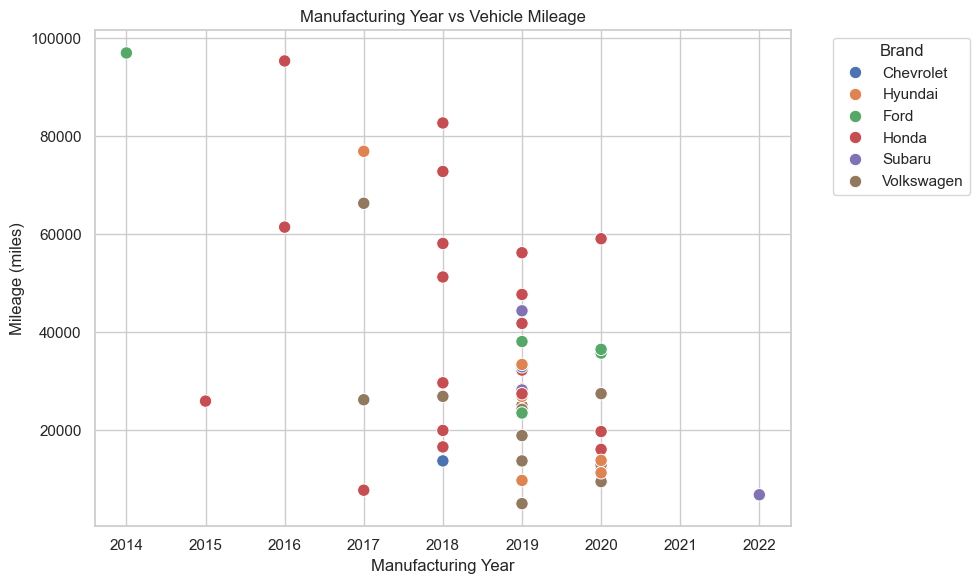

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cars,
    x="year",
    y="miles",
    hue="brand",
    s=80
)

plt.title("Manufacturing Year vs Vehicle Mileage")
plt.xlabel("Manufacturing Year")
plt.ylabel("Mileage (miles)")
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Analysis

The scatter plot allows us to observe how mileage varies across different
manufacturing years.

The relationship should be interpreted carefully because mileage depends on
how much each individual vehicle has been used, and the dataset contains only
52 observations.

## 12. City and Highway Fuel Efficiency

The dataset contains separate fuel-efficiency measurements for city and
highway driving.

We compare these two variables to understand how fuel efficiency differs
between the two driving conditions.

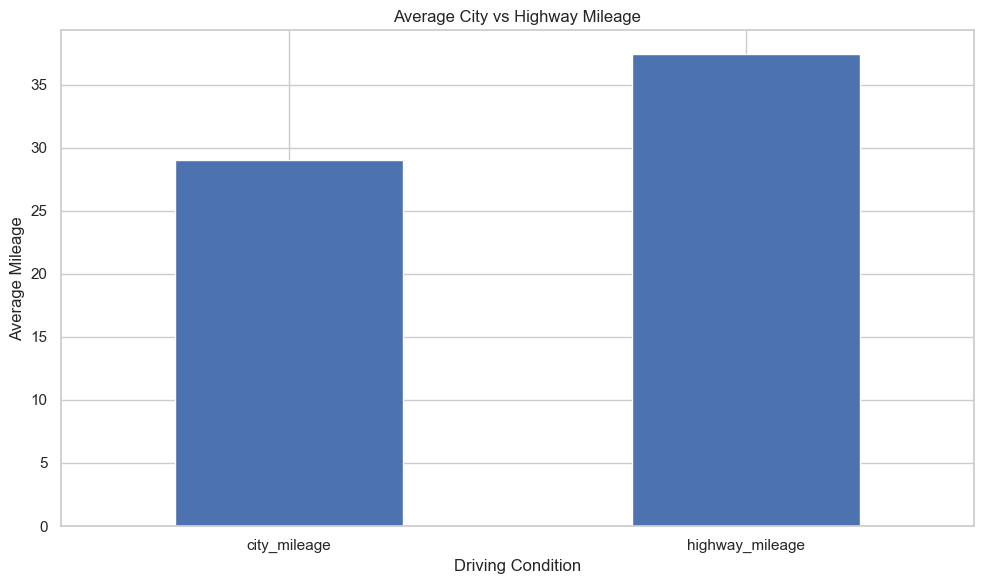

In [29]:
plt.figure(figsize=(10, 6))

cars[["city_mileage", "highway_mileage"]].mean().plot(
    kind="bar"
)

plt.title("Average City vs Highway Mileage")
plt.xlabel("Driving Condition")
plt.ylabel("Average Mileage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
print("Average city mileage:", cars["city_mileage"].mean())
print("Average highway mileage:", cars["highway_mileage"].mean())

Average city mileage: 29.03846153846154
Average highway mileage: 37.42307692307692


### Analysis

The average highway mileage can be compared with the average city mileage
to understand the overall difference in fuel efficiency between the two
driving conditions represented in the dataset.

## 13. Brand-wise Fuel Efficiency

Next, we compare the average city and highway mileage across different brands.

This allows us to observe how fuel-efficiency measurements vary among the
brands represented in the dataset.

In [31]:
brand_mileage = cars.groupby("brand")[[
    "city_mileage",
    "highway_mileage"
]].mean()

brand_mileage

,city_mileage,highway_mileage
brand,,
Chevrolet,31.33,36.67
Ford,21.00,30.00
Honda,32.17,39.70
Hyundai,27.29,36.29
Subaru,27.67,37.00
Volkswagen,27.00,37.09


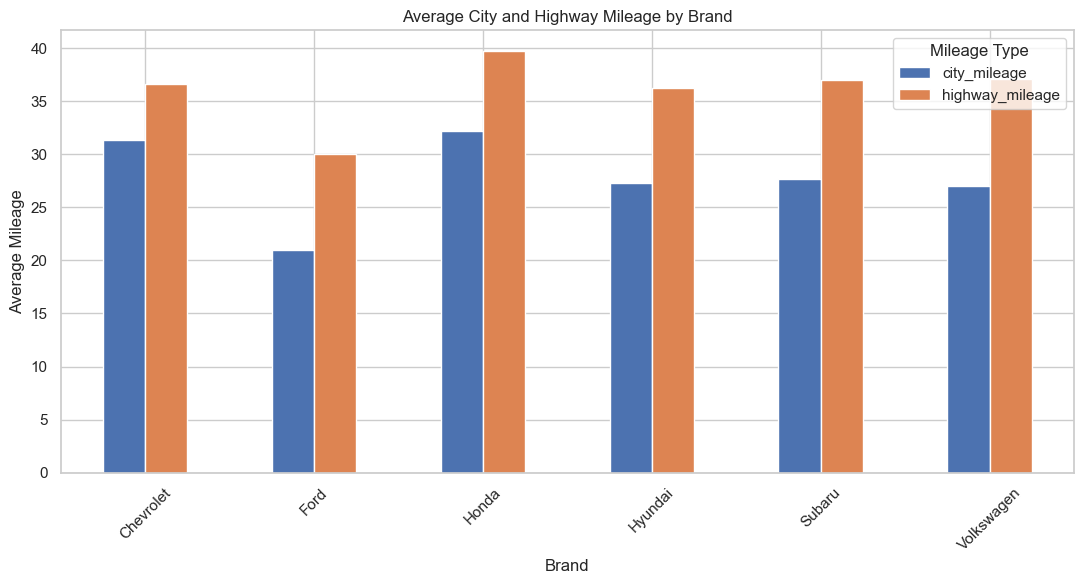

In [32]:
brand_mileage.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Average City and Highway Mileage by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Mileage")
plt.xticks(rotation=45)
plt.legend(title="Mileage Type")
plt.tight_layout()
plt.show()

## 14. Horsepower Analysis

Horsepower is an important measure of engine performance.

We examine the distribution of horsepower values and compare horsepower
across different brands.

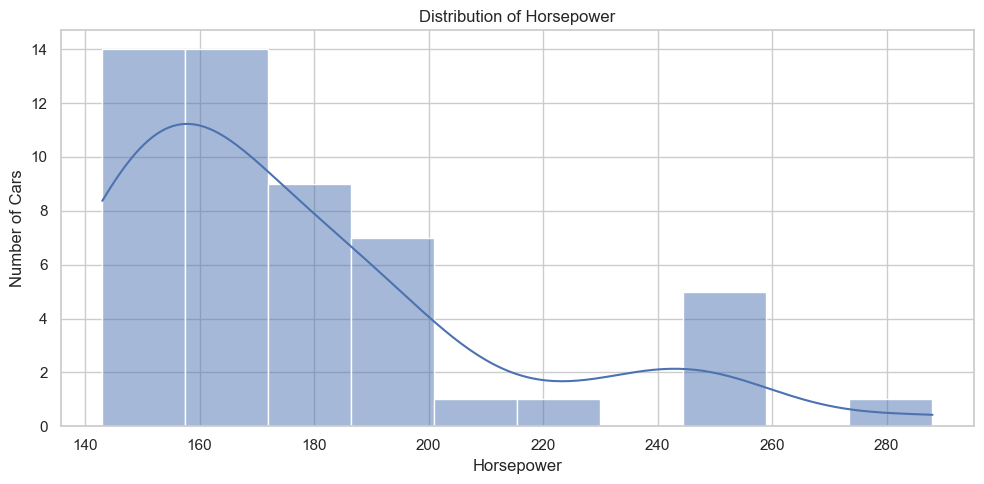

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=cars,
    x="horsepower",
    bins=10,
    kde=True
)

plt.title("Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

In [34]:
brand_hp = cars.groupby("brand")["horsepower"].mean().sort_values(ascending=False)

brand_hp

brand
Ford         236.40
Chevrolet    186.33
Honda        171.83
Hyundai      171.71
Volkswagen   165.09
Subaru       162.00
Name: horsepower, dtype: float64

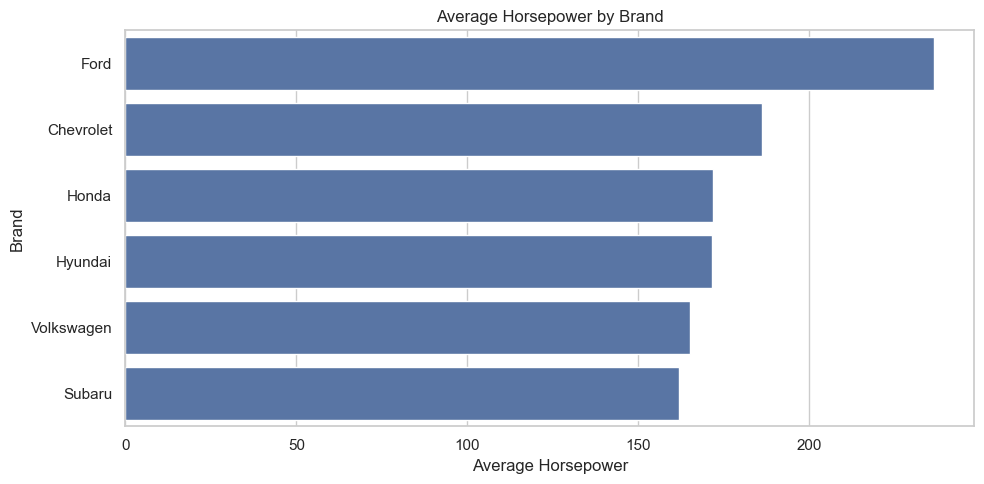

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=brand_hp.values,
    y=brand_hp.index
)

plt.title("Average Horsepower by Brand")
plt.xlabel("Average Horsepower")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

## 15. Engine Capacity vs Horsepower

We investigate whether cars with larger engine capacities tend to have
higher horsepower.

A scatter plot is used to visualize the relationship between engine capacity
and horsepower.

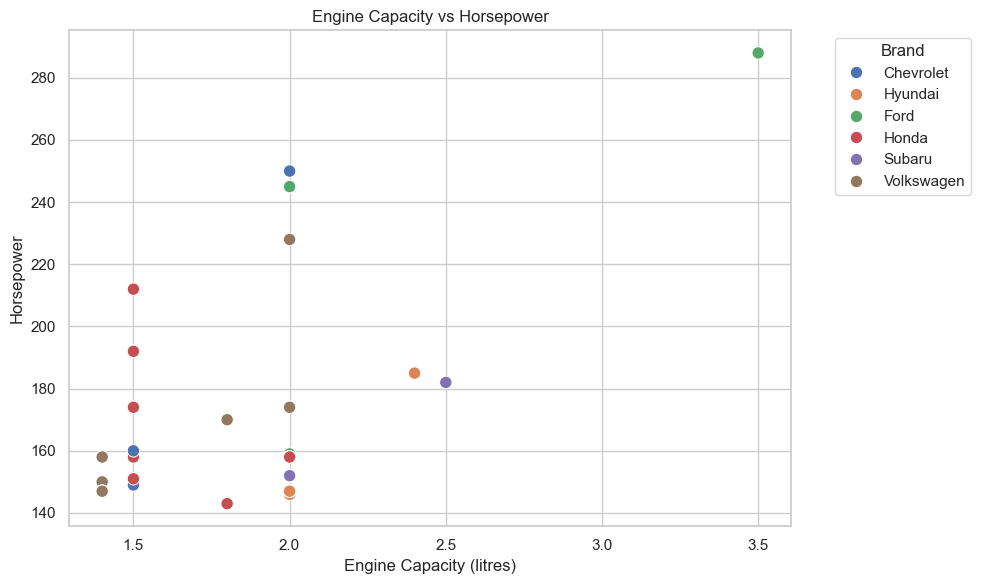

In [36]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cars,
    x="engine_capacity_litre",
    y="horsepower",
    hue="brand",
    s=80
)

plt.title("Engine Capacity vs Horsepower")
plt.xlabel("Engine Capacity (litres)")
plt.ylabel("Horsepower")
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 16. Engine Capacity vs Torque

Torque is another important measure of engine characteristics.

We examine whether engine capacity is associated with torque in the cars
included in the dataset.

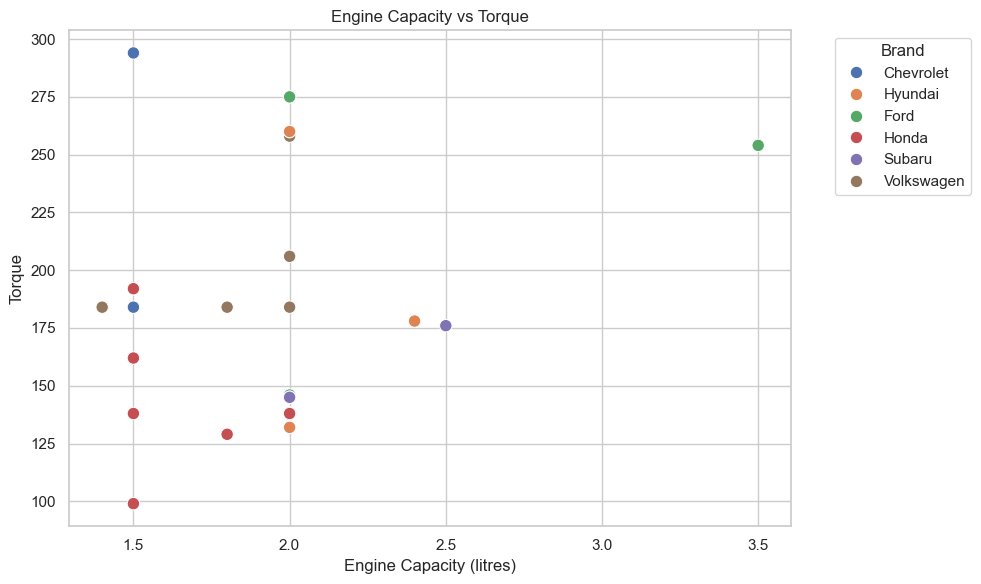

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cars,
    x="engine_capacity_litre",
    y="torque",
    hue="brand",
    s=80
)

plt.title("Engine Capacity vs Torque")
plt.xlabel("Engine Capacity (litres)")
plt.ylabel("Torque")
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 17. Correlation Analysis

Correlation measures the strength and direction of a linear relationship
between numerical variables.

A positive correlation indicates that two variables tend to increase
together, while a negative correlation indicates that one variable tends to
decrease as the other increases.

Correlation does not imply causation.

In [38]:
numeric_columns = [
    "year",
    "miles",
    "city_mileage",
    "highway_mileage",
    "horsepower",
    "torque",
    "engine_capacity_litre"
]

correlation_matrix = cars[numeric_columns].corr()

correlation_matrix

,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre
year,1.00,-0.57,-0.08,-0.17,0.25,0.32,0.08
miles,-0.57,1.00,0.11,0.12,-0.07,-0.21,-0.05
city_mileage,-0.08,0.11,1.00,0.85,-0.49,-0.52,-0.52
highway_mileage,-0.17,0.12,0.85,1.00,-0.76,-0.66,-0.65
horsepower,0.25,-0.07,-0.49,-0.76,1.00,0.70,0.40
torque,0.32,-0.21,-0.52,-0.66,0.70,1.00,0.12
engine_capacity_litre,0.08,-0.05,-0.52,-0.65,0.40,0.12,1.00


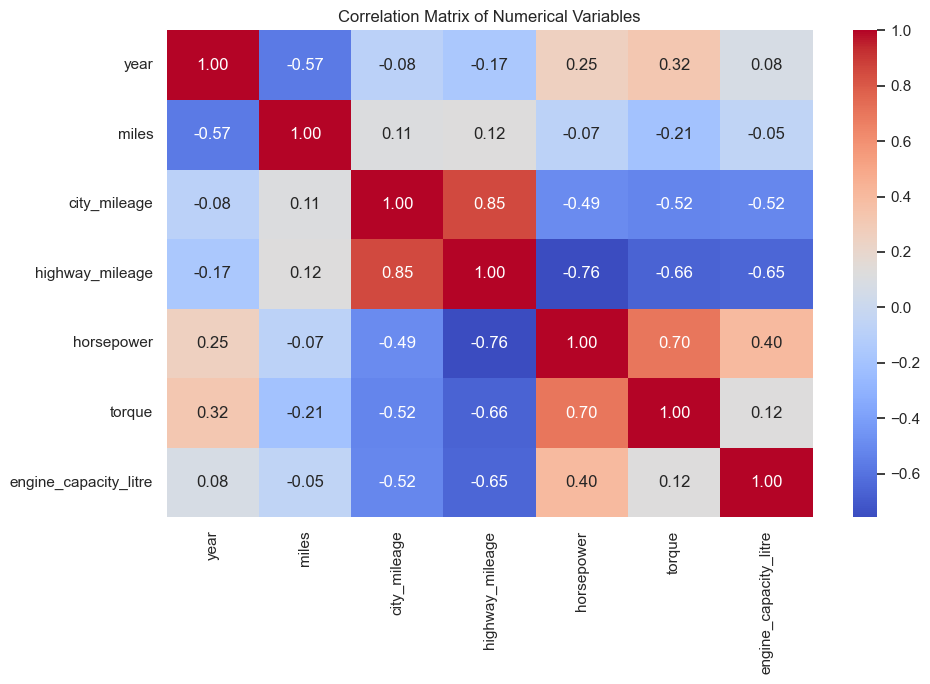

In [39]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 18. Cars with Higher Horsepower

To understand the performance characteristics of the dataset, we identify
the cars with the highest horsepower values.

In [40]:
top_horsepower = cars.sort_values(
    by="horsepower",
    ascending=False
)[[
    "brand",
    "model",
    "year",
    "horsepower",
    "torque",
    "engine_capacity_litre"
]]

top_horsepower.head(10)

,brand,model,year,horsepower,torque,engine_capacity_litre
20,Ford,Taurus,2019,288,254,3.50
36,Chevrolet,Malibu,2018,250,260,2.00
21,Ford,Fusion,2020,245,275,2.00
39,Ford,Fusion,2020,245,275,2.00
49,Ford,Fusion,2019,245,275,2.00
47,Hyundai,Sonata,2019,245,260,2.00
33,Volkswagen,Jetta,2020,228,258,2.00
7,Honda,Clarity,2018,212,99,1.50
26,Honda,Accord,2020,192,192,1.50
51,Honda,Accord,2018,192,192,1.50


## 19. Cars with Higher Fuel Efficiency

We identify vehicles with higher highway mileage to examine the cars that
have stronger fuel-efficiency measurements in the dataset.

In [41]:
fuel_efficient = cars.sort_values(
    by="highway_mileage",
    ascending=False
)[[
    "brand",
    "model",
    "year",
    "city_mileage",
    "highway_mileage"
]]

fuel_efficient.head(10)

,brand,model,year,city_mileage,highway_mileage
18,Honda,Insight,2019,55,49
0,Chevrolet,Volt LT,2019,43,42
11,Honda,Civic,2019,32,42
3,Honda,Civic,2016,31,42
14,Honda,Civic,2020,32,42
41,Honda,Civic,2019,32,42
5,Honda,Civic,2016,31,41
12,Honda,Civic,2018,31,40
8,Volkswagen,Jetta,2019,30,40
7,Honda,Clarity,2018,44,40


In [42]:
print("Number of cars:", len(cars))
print("Number of brands:", cars["brand"].nunique())
print("Number of models:", cars["model"].nunique())

print("\nMost common brand:")
print(cars["brand"].value_counts().idxmax())

print("\nHighest horsepower:")
print(cars.loc[cars["horsepower"].idxmax(), 
              ["brand", "model", "horsepower"]])

print("\nHighest highway mileage:")
print(cars.loc[cars["highway_mileage"].idxmax(), 
              ["brand", "model", "highway_mileage"]])

print("\nAverage city mileage:", round(cars["city_mileage"].mean(), 2))
print("Average highway mileage:", round(cars["highway_mileage"].mean(), 2))

Number of cars: 52
Number of brands: 6
Number of models: 15

Most common brand:
Honda

Highest horsepower:
brand           Ford
model         Taurus
horsepower       288
Name: 20, dtype: object

Highest highway mileage:
brand                Honda
model              Insight
highway_mileage         49
Name: 18, dtype: object

Average city mileage: 29.04
Average highway mileage: 37.42


## 20. Key Findings

Based on the analysis, the following observations were made:

1. The dataset contains 52 used cars representing multiple brands and models.
2. The distribution of cars varies across different brands and models.
3. City and highway mileage show differences in fuel-efficiency measurements.
4. Horsepower and torque vary considerably across the vehicles.
5. Engine capacity shows a relationship with performance-related variables
   such as horsepower and torque.
6. The correlation matrix helps identify relationships among the numerical
   variables.
7. The results describe patterns within this particular dataset and should
   not be generalized to all used cars.

## 21. Conclusion

This project explored a dataset of used cars to understand patterns in
vehicle characteristics, performance, and fuel efficiency.

The analysis involved data inspection, data cleaning, exploratory data
analysis, statistical summaries, and visualization.

Several relationships between engine characteristics and vehicle performance
were explored using scatter plots and correlation analysis. Brand-wise
comparisons were also performed for fuel efficiency and horsepower.

Overall, the project demonstrates how Python and data-analysis libraries can
be used to transform a raw dataset into meaningful insights.

### Limitations

- The dataset contains only 52 observations.
- The dataset does not contain vehicle price information.
- The analysis is descriptive and does not establish causal relationships.
- The results may not represent the complete used-car market.